### **Importing Libraries**

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

### **Importing data**

we name the first original dataframe as df1, as the dataframe gets cleaned the number will increase (df1-->df2)

In [30]:
df = pd.read_csv("data/housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### **Exploratory Data Analysis (EDA) and Data Cleaning**

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Notice that total_bedrooms has missing values with only 20433 non-null instead of 20640 we will then check the exact number and percentage of missing values to see if it is significant enough to drop the variable (toatl_bedrooms).

In [32]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [33]:
(df.isna().sum()/len(df))*100

longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64

at a 1.0029 percent, missing vals arent significant enough to drop entire column so we drop rows instead

In [34]:
df.shape

(20640, 10)

In [35]:
df = df.dropna()
df.shape

(20433, 10)

although unnecessary for Machine learning but it is best pratice in Data cleaning to change float data types that shouldnt be to integers

In [36]:
cols = df.columns[2:7] #until households
df[cols] = df[cols].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  int64  
 3   total_rooms         20433 non-null  int64  
 4   total_bedrooms      20433 non-null  int64  
 5   population          20433 non-null  int64  
 6   households          20433 non-null  int64  
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(4), int64(5), object(1)
memory usage: 1.7+ MB


### **One-Hot-Encoding for "ocean_proximity" variable**

In [37]:
ocean_proximity_dummies = pd.get_dummies(df["ocean_proximity"],"ocean_prox")
ocean_proximity_dummies.head()

,ocean_prox_<1H OCEAN,ocean_prox_INLAND,ocean_prox_ISLAND,ocean_prox_NEAR BAY,ocean_prox_NEAR OCEAN
0,False,False,False,True,False
1,False,False,False,True,False
2,False,False,False,True,False
3,False,False,False,True,False
4,False,False,False,True,False


In [ ]:
ocean_proximity_dummies = ocean_proximity_dummies.astype(int) # change from bool to int
ocean_proximity_dummies.head()

,ocean_prox_<1H OCEAN,ocean_prox_INLAND,ocean_prox_ISLAND,ocean_prox_NEAR BAY,ocean_prox_NEAR OCEAN
0,0,0,0,1,0
1,0,0,0,1,0
2,0,0,0,1,0
3,0,0,0,1,0
4,0,0,0,1,0


To prevent Multicollinearity caused by creating dummy variables (so called the "dummy trap") we must drop at least one of the created dummy variables

In [ ]:
ocean_proximity_dummies = ocean_proximity_dummies.iloc[:, 1:] #excluded 1st column
ocean_proximity_dummies.head()

,ocean_prox_INLAND,ocean_prox_ISLAND,ocean_prox_NEAR BAY,ocean_prox_NEAR OCEAN
0,0,0,1,0
1,0,0,1,0
2,0,0,1,0
3,0,0,1,0
4,0,0,1,0


In [48]:
df = df.drop(df.columns[-1], axis=1)
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41,880,129,322,126,8.3252,452600.0
1,-122.22,37.86,21,7099,1106,2401,1138,8.3014,358500.0
2,-122.24,37.85,52,1467,190,496,177,7.2574,352100.0
3,-122.25,37.85,52,1274,235,558,219,5.6431,341300.0
4,-122.25,37.85,52,1627,280,565,259,3.8462,342200.0
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374,845,330,1.5603,78100.0
20636,-121.21,39.49,18,697,150,356,114,2.5568,77100.0
20637,-121.22,39.43,17,2254,485,1007,433,1.7000,92300.0
20638,-121.32,39.43,18,1860,409,741,349,1.8672,84700.0


Concat the two dataframes (df and dummies)

In [50]:
df = pd.concat([df,ocean_proximity_dummies],axis=1)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_prox_INLAND,ocean_prox_ISLAND,ocean_prox_NEAR BAY,ocean_prox_NEAR OCEAN,ocean_prox_INLAND,ocean_prox_ISLAND,ocean_prox_NEAR BAY,ocean_prox_NEAR OCEAN
0,-122.23,37.88,41,880,129,322,126,8.3252,452600.0,0,0,1,0,0,0,1,0
1,-122.22,37.86,21,7099,1106,2401,1138,8.3014,358500.0,0,0,1,0,0,0,1,0
2,-122.24,37.85,52,1467,190,496,177,7.2574,352100.0,0,0,1,0,0,0,1,0
3,-122.25,37.85,52,1274,235,558,219,5.6431,341300.0,0,0,1,0,0,0,1,0
4,-122.25,37.85,52,1627,280,565,259,3.8462,342200.0,0,0,1,0,0,0,1,0


### **Plotting Distributions and Accessing Model Assumptions**

In the multiple Linear Regression model there are 4 main Preliminary assumptions

1. Dependent variables(Xi) are known and independant
2. The Response(Yi) has a normal distribution with a mean of 0 and a constant variance
3. There is a linear Relationship between independent(Yi) and dependent(Xi) variables
4. Residuals(ei) are independant and has a normal distribution with a mean of 0 and a constant varience

Since our Dependent variables are known we will start by checking if our dependent variables have **Multicollinearity (Assumption 1)**

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df,annot=True)
plt.show()

KeyboardInterrupt: 

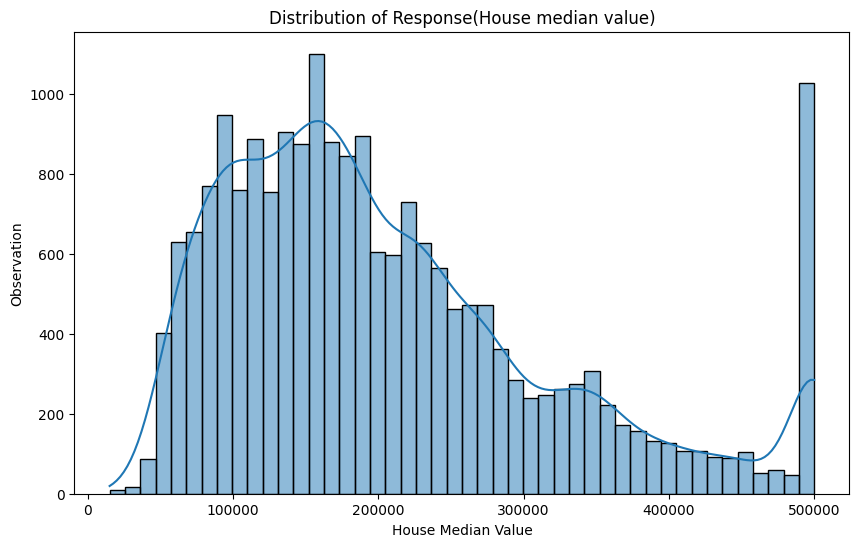

In [53]:
plt.figure(figsize=(10,6))
sns.histplot(df["median_house_value"],kde = True)
plt.title("Distribution of Response(House median value)")
plt.xlabel("House Median Value")
plt.ylabel("Observation")
plt.show()